In [4]:
import os
import librosa
import librosa.display
import IPython.display as ipd
import numpy as np
import matplotlib.pyplot as plt

## Loading audio files with Librosa

In [ ]:
scale_file = "../audio/scale.wav"
debussy_file = "../audio/debussy.wav"
redhot_file = "../audio/redhot.wav"
duke_file = "../audio/duke.wav"

In [12]:
ipd.Audio(scale_file)

ValueError: rate must be specified when data is a numpy array or list of audio samples.

In [ ]:
ipd.Audio(debussy_file)

In [ ]:
ipd.Audio(redhot_file)

In [ ]:
ipd.Audio(duke_file)

In [ ]:
# load audio files with librosa
scale, sr = librosa.load(scale_file)
debussy, _ = librosa.load(debussy_file)
redhot, _ = librosa.load(redhot_file)
duke, _ = librosa.load(duke_file)

## Extracting Short-Time Fourier Transform

In [ ]:
FRAME_SIZE = 2048
HOP_SIZE = 512

In [ ]:
S_scale = librosa.stft(scale, n_fft=FRAME_SIZE, hop_length=HOP_SIZE)

In [ ]:
S_scale.shape

(1025, 342)

In [ ]:
type(S_scale[0][0])

numpy.complex64

## Calculating the spectrogram

In [ ]:
Y_scale = np.abs(S_scale) ** 2

In [ ]:
Y_scale.shape

(1025, 342)

In [ ]:
type(Y_scale[0][0])

numpy.float32

## Visualizing the spectrogram

In [ ]:
def plot_spectrogram(Y, sr, hop_length, y_axis="linear"):
    plt.figure(figsize=(25, 10))
    librosa.display.specshow(Y, 
                             sr=sr, 
                             hop_length=hop_length, 
                             x_axis="time", 
                             y_axis=y_axis)
    plt.colorbar(format="%+2.f")

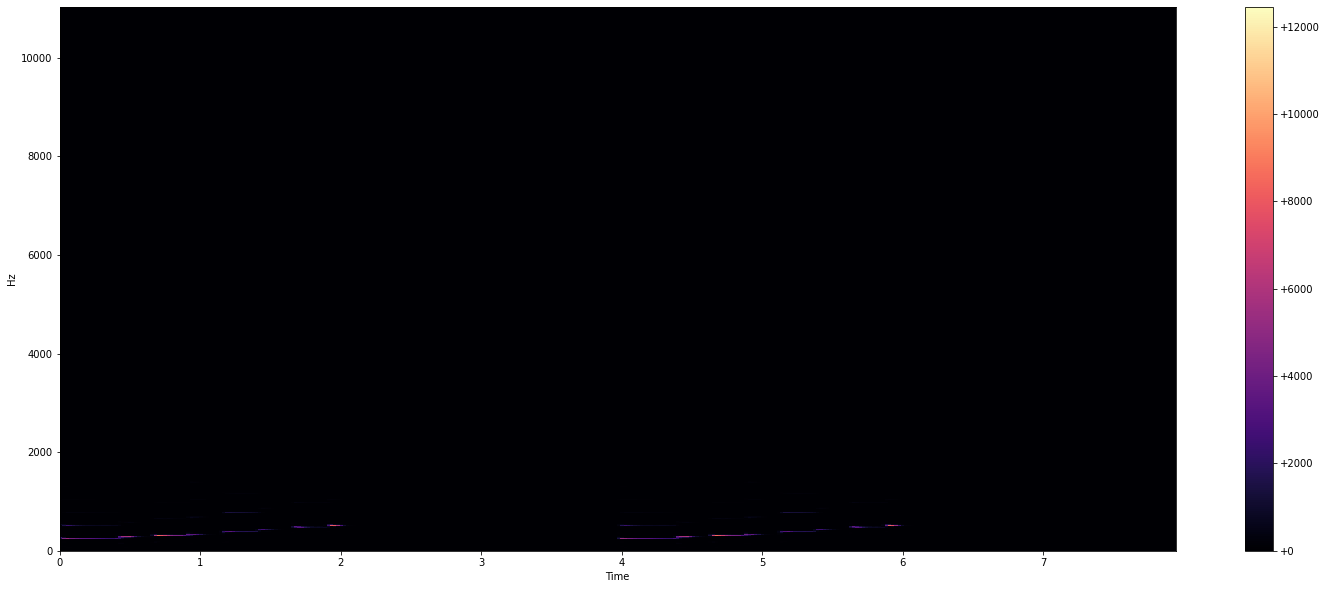

In [ ]:
plot_spectrogram(Y_scale, sr, HOP_SIZE)

## Log-Amplitude Spectrogram

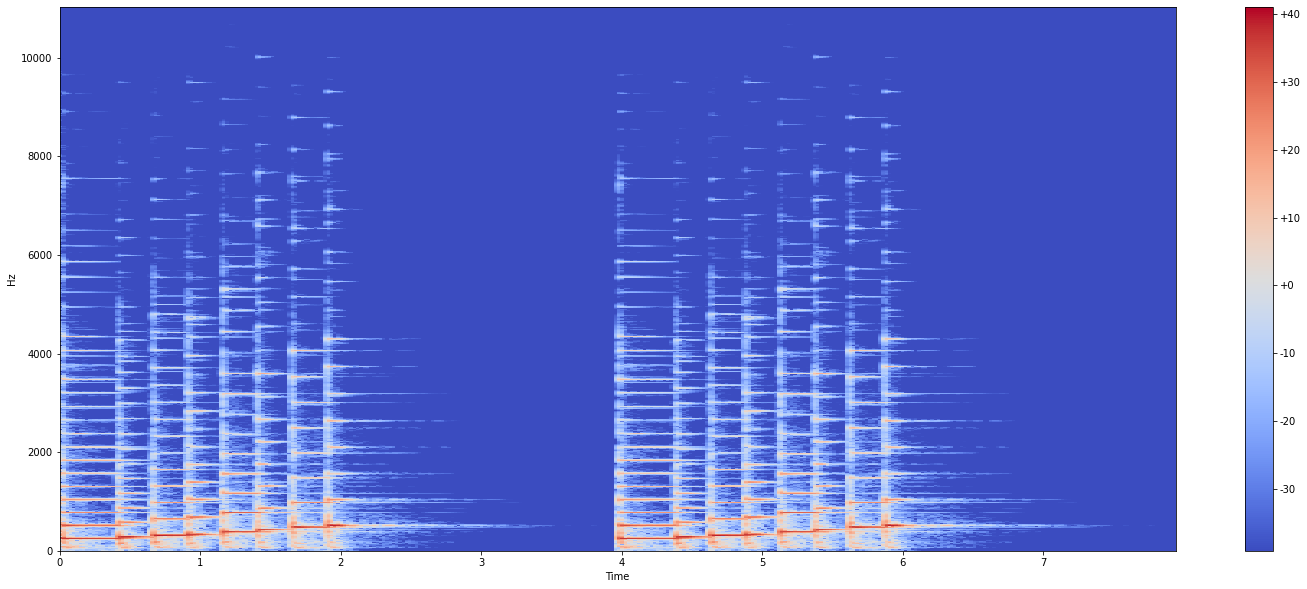

In [ ]:
Y_log_scale = librosa.power_to_db(Y_scale)
plot_spectrogram(Y_log_scale, sr, HOP_SIZE)

## Log-Frequency Spectrogram

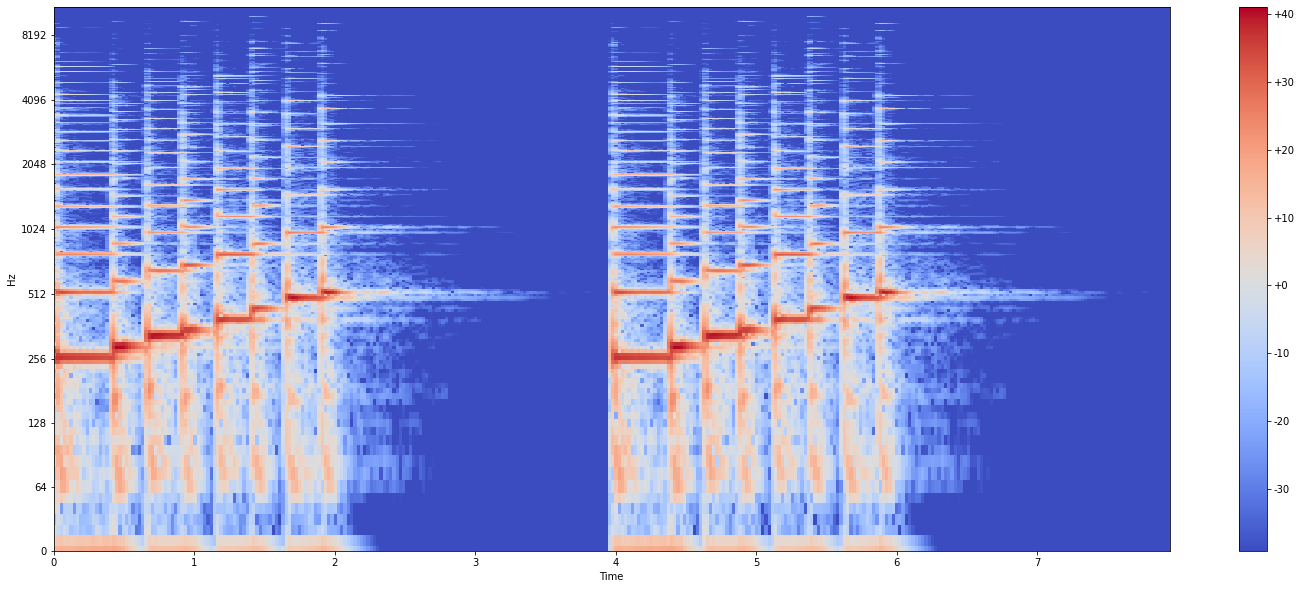

In [ ]:
plot_spectrogram(Y_log_scale, sr, HOP_SIZE, y_axis="log")

## Visualising songs from different genres

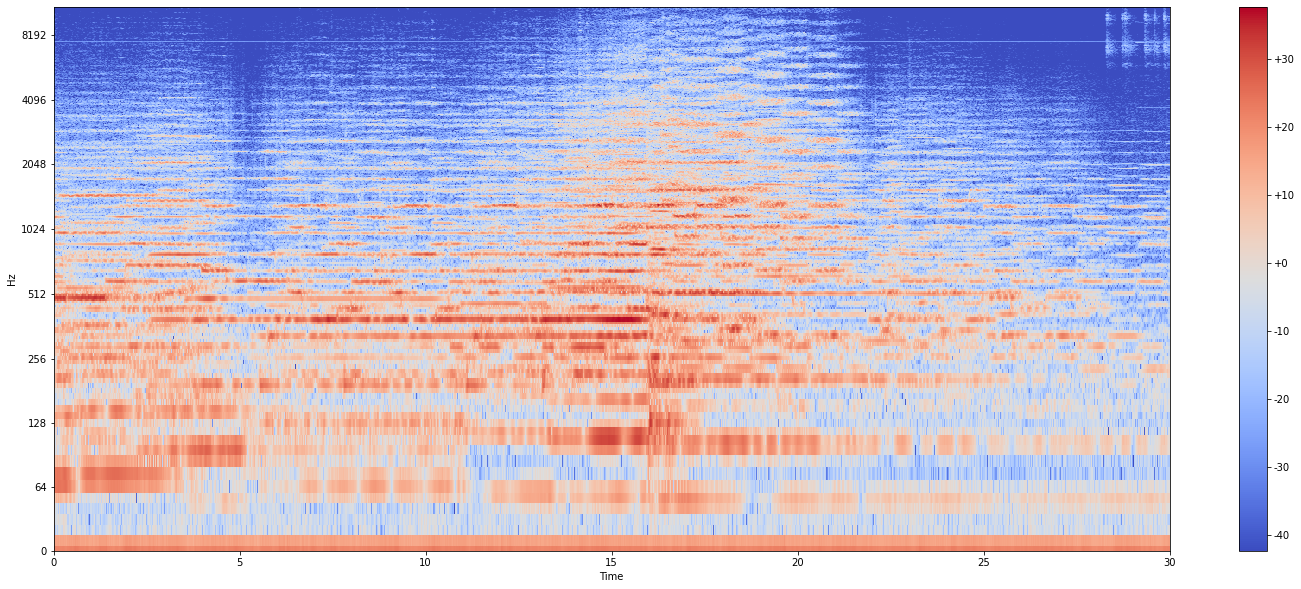

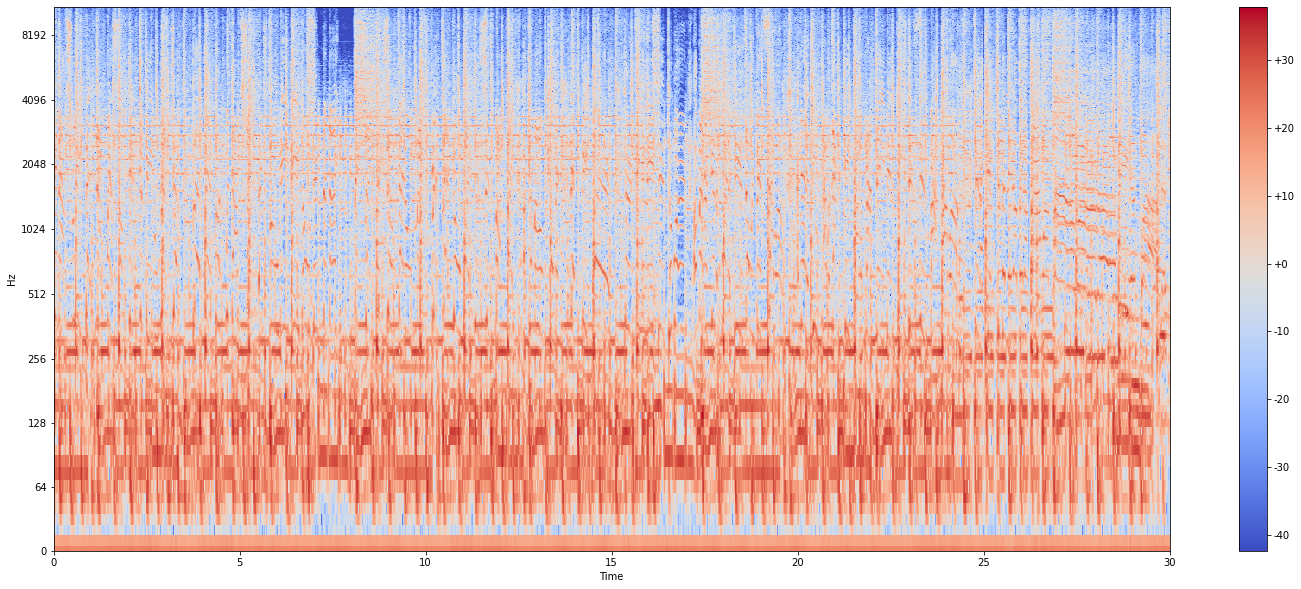

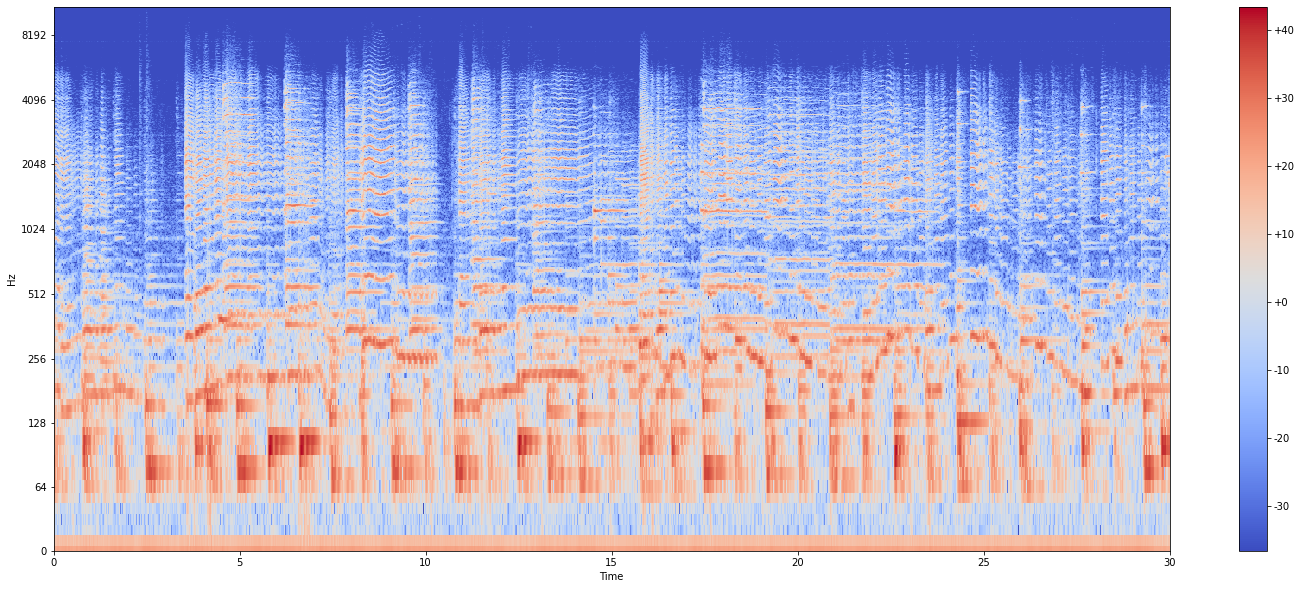

In [ ]:
S_debussy = librosa.stft(debussy, n_fft=FRAME_SIZE, hop_length=HOP_SIZE)
S_redhot = librosa.stft(redhot, n_fft=FRAME_SIZE, hop_length=HOP_SIZE)
S_duke = librosa.stft(duke, n_fft=FRAME_SIZE, hop_length=HOP_SIZE)


Y_debussy = librosa.power_to_db(np.abs(S_debussy) ** 2)
Y_redhot = librosa.power_to_db(np.abs(S_redhot) ** 2)
Y_duke = librosa.power_to_db(np.abs(S_duke) ** 2)

plot_spectrogram(Y_debussy, sr, HOP_SIZE, y_axis="log")
plot_spectrogram(Y_redhot, sr, HOP_SIZE, y_axis="log")
plot_spectrogram(Y_duke, sr, HOP_SIZE, y_axis="log")